In [1]:
import asyncio
import websockets
import json
import pandas as pd
import numpy as np
import nest_asyncio # Import nest_asyncio

In [2]:
## Async functions and logic

# Apply nest_asyncio to allow nested event loops to run within the notebook thread.
nest_asyncio.apply()

# An asyncio-safe queue to pass data between coroutines
data_queue_async = asyncio.Queue()

# A list to buffer records before turning them into a DataFrame
# This avoids frequent DataFrame re-creations which can be inefficient
# You might want to cap its size or process it after N items.
records_buffer = []
df_lock_async = asyncio.Lock() # For async-safe DataFrame access

# Global DataFrame
current_df_async = pd.DataFrame()

async def receive_websocket_data(uri, initial_message):
    try:
        async with websockets.connect(uri) as websocket:
            print(f"Connected to {uri}")
            initial_message = json.dumps(initial_message)
            await websocket.send(initial_message)
            print(f"Sent: {initial_message}")

            while True:
                try:
                    response = await websocket.recv()
                    data = json.loads(response)
                    await data_queue_async.put(data) # Put data into the async queue
                    # print(f"Async: Received and queued: {data}")
                except websockets.exceptions.ConnectionClosedOK:
                    print("Connection closed gracefully.")
                    break
                except websockets.exceptions.ConnectionClosedError as e:
                    print(f"Connection closed with error: {e}")
                    break
                except json.JSONDecodeError:
                    print(f"Async: Received non-JSON message: {response}")
                except Exception as e:
                    print(f"Async: Error in receive loop: {e}")
    except Exception as e:
        print(f"Could not connect to WebSocket at {uri}: {e}")


async def update_dataframe_task(seconds=5, num_samples=False):
    """Periodically takes data from the queue and updates the DataFrame."""
    global current_df_async, records_buffer

    while True:
        # Check for new data in the queue
        while not data_queue_async.empty():
            item = await data_queue_async.get()
            records_buffer.append(item)
            # You can add logic here to process/discard older items if buffer gets too large

        # Update DataFrame periodically or when buffer reaches a certain size
        if records_buffer: # Only update if there's new data
            # Use a copy of the buffer to allow new items to be added while processing
            records_to_process = list(records_buffer)
            records_buffer.clear() # Clear the buffer after copying

            new_df_segment = pd.DataFrame(records_to_process)

            # Sample the dataframe, since the websocket gives too much information
            if num_samples:
                # Calculate evenly spaced indices
                evenly_spaced_indices = np.linspace(0, len(new_df_segment) - 1, num_samples).astype(int)

                # Select rows from the DataFrame using these indices
                new_df_segment = new_df_segment.iloc[evenly_spaced_indices]


            async with df_lock_async: # Acquire async lock
                if current_df_async.empty:
                    current_df_async = new_df_segment
                else:
                    current_df_async = pd.concat([current_df_async, new_df_segment], ignore_index=True)
                print(f"\nAsync: DataFrame updated. Current size: {len(current_df_async)} rows.")
                print("Async: Current DataFrame head:")
                print(current_df_async.tail()) # Show last few rows

        await asyncio.sleep(seconds) # Check and update every x seconds


async def main_async(initial_message):

    # --- URI Construction ---
    import os
    from dotenv import load_dotenv
    from urllib.parse import urlencode, urlunparse

    load_dotenv()  # This loads variables from .env into os.environ
    coinapi_apikey = os.getenv("coinapi_apikey")

    ### basic websocket
    # coinapi_wss = "ws.coinapi.io/v1"
    ### advanced websocket, enabling easy switching between data exchanges or sources
    exchange_name = "coinbase"
    coinapi_wss = exchange_name+".ws-ds.md.coinapi.io"

    base_uri_ws = coinapi_wss
    api_key_ws = coinapi_apikey
    query_params_ws = {
        # "": "BTC",
        "apikey": api_key_ws, # The parameter name might vary by API
    }
    encoded_query_params_ws = urlencode(query_params_ws)
    websocket_uri_ws = urlunparse(
        ("wss", base_uri_ws, "BTC", "", encoded_query_params_ws, "")
    )
    # --- End URI Construction ---

    # Start the WebSocket client and DataFrame updater as concurrent tasks
    consumer_task = asyncio.create_task(receive_websocket_data(websocket_uri_ws, initial_message))
    updater_task = asyncio.create_task(update_dataframe_task(seconds=5, num_samples=None))

    # Keep the event loop running
    await asyncio.gather(consumer_task, updater_task)

In [3]:
# Sending hello message as per: https://docs.coinapi.io/market-data/websocket-ds/general

# initial_message = {
#     "type": "hello",
#     "heartbeat": False,
#     "subscribe_data_type": ["quote"],
#     "subscribe_filter_asset_id": ["BTC"],
#     "subscribe_filter_symbol_id": [
#         "COINBASE_SPOT_BTC_USD",
#     ]
# }

initial_message = {
  "type": "hello",
  "heartbeat": False,
  "subscribe_data_type": ["trade"],
  "subscribe_filter_asset_id": ["BTC"],
  "subscribe_filter_symbol_id": [
    "COINBASE_SPOT_BTC_USD",
  ]
}

try:
    # Directly await main_async after nest_asyncio.apply()
    await main_async(initial_message)
except KeyboardInterrupt:
    print("\nAsync: Stopping program.")

Connected to wss://coinbase.ws-ds.md.coinapi.io/BTC?apikey=fd2eaeda-42fe-4c0a-90f9-2433cf3dfaaf
Sent: {"type": "hello", "heartbeat": false, "subscribe_data_type": ["trade"], "subscribe_filter_asset_id": ["BTC"], "subscribe_filter_symbol_id": ["COINBASE_SPOT_BTC_USD"]}

Async: DataFrame updated. Current size: 29 rows.
Async: Current DataFrame head:
                   time_exchange                  time_coinapi  \
24  2025-11-26T06:35:28.0224510Z  2025-11-26T06:35:28.0296805Z   
25  2025-11-26T06:35:28.0224510Z  2025-11-26T06:35:28.0299191Z   
26  2025-11-26T06:35:28.0224510Z  2025-11-26T06:35:28.0300777Z   
27  2025-11-26T06:35:28.0224510Z  2025-11-26T06:35:28.0301618Z   
28  2025-11-26T06:35:28.0224510Z  2025-11-26T06:35:28.0302342Z   

                                    uuid    price      size taker_side  \
24  80f76506-c001-419f-8e36-bc394c1cb963  87457.0  0.039830       SELL   
25  239c167c-d734-42b9-8f4d-8d33f267e895  87457.0  0.038460       SELL   
26  5f02f1e7-284b-4ad9-afd9-b35

CancelledError: 

In [4]:
df = current_df_async
df.to_csv('bitcoin_sample_data_large.csv', index=False)

In [ ]:
print(df.tail)

In [5]:
# We use 'time_exchange' as it represents the actual event time on the matching engine
resampled_df = df.copy()
resampled_df['time_exchange'] = pd.to_datetime(resampled_df['time_exchange'])

# 3. Set the datetime column as the Dataframe Index
resampled_df.set_index('time_exchange', inplace=True)

# 4. Resample
# '1S' = 1 Second, '1T' = 1 Minute, '1H' = 1 Hour
# We aggregate Price into OHLC and Size into Sum (Volume)
resampled_df = resampled_df.resample('1S').agg({
    'price': 'ohlc',  # Open, High, Low, Close
    'size': 'sum'     # Total Volume
})


# 5. Flatten the column headers (optional, cleans up the MultiIndex)
resampled_df.columns = ['open', 'high', 'low', 'close', 'volume']

# Handle missing intervals (if no trades occurred in a second)
# forward fill prices, fill volume with 0
resampled_df['close'] = resampled_df['close'].ffill()
resampled_df['open'] = resampled_df['open'].fillna(resampled_df['close'])
resampled_df['high'] = resampled_df['high'].fillna(resampled_df['close'])
resampled_df['low'] = resampled_df['low'].fillna(resampled_df['close'])
resampled_df['volume'] = resampled_df['volume'].fillna(0)

print(resampled_df.tail)

<bound method NDFrame.tail of                                open      high       low     close    volume
time_exchange                                                              
2025-11-26 06:35:24+00:00  87447.58  87447.58  87447.58  87447.58  0.002231
2025-11-26 06:35:25+00:00  87447.58  87447.58  87447.58  87447.58  0.004461
2025-11-26 06:35:26+00:00  87447.58  87455.20  87447.58  87455.20  0.541926
2025-11-26 06:35:27+00:00  87457.01  87457.01  87457.01  87457.01  0.001000
2025-11-26 06:35:28+00:00  87457.00  87457.00  87457.00  87457.00  0.200000
...                             ...       ...       ...       ...       ...
2025-11-26 07:37:06+00:00  87755.90  87755.90  87755.90  87755.90  0.000000
2025-11-26 07:37:07+00:00  87755.92  87756.35  87755.92  87756.35  0.003037
2025-11-26 07:37:08+00:00  87757.80  87757.80  87757.80  87757.80  0.000191
2025-11-26 07:37:09+00:00  87757.80  87757.80  87751.05  87751.05  1.375467
2025-11-26 07:37:10+00:00  87746.21  87746.21  87746.20  8

In [6]:
resampled_df_noindex = resampled_df.copy()

# 2. Name the index (optional, ensures the new column has a name)
resampled_df_noindex.index.name = 'time_exchange'

# 3. Reset index to move Timestamp into the dataframe as a normal column
resampled_df_noindex = resampled_df_noindex.reset_index()

print(resampled_df_noindex.tail)


<bound method NDFrame.tail of                  time_exchange      open      high       low     close  \
0    2025-11-26 06:35:24+00:00  87447.58  87447.58  87447.58  87447.58   
1    2025-11-26 06:35:25+00:00  87447.58  87447.58  87447.58  87447.58   
2    2025-11-26 06:35:26+00:00  87447.58  87455.20  87447.58  87455.20   
3    2025-11-26 06:35:27+00:00  87457.01  87457.01  87457.01  87457.01   
4    2025-11-26 06:35:28+00:00  87457.00  87457.00  87457.00  87457.00   
...                        ...       ...       ...       ...       ...   
3702 2025-11-26 07:37:06+00:00  87755.90  87755.90  87755.90  87755.90   
3703 2025-11-26 07:37:07+00:00  87755.92  87756.35  87755.92  87756.35   
3704 2025-11-26 07:37:08+00:00  87757.80  87757.80  87757.80  87757.80   
3705 2025-11-26 07:37:09+00:00  87757.80  87757.80  87751.05  87751.05   
3706 2025-11-26 07:37:10+00:00  87746.21  87746.21  87746.20  87746.20   

        volume  
0     0.002231  
1     0.004461  
2     0.541926  
3     0.00100

In [ ]:
# avg values for time series frequenency is same as sampling frequency by default, handle for other cases

# df.resample

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

c:\Users\alebr\Desktop\Engineering\AO\Projects\timecopilot\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


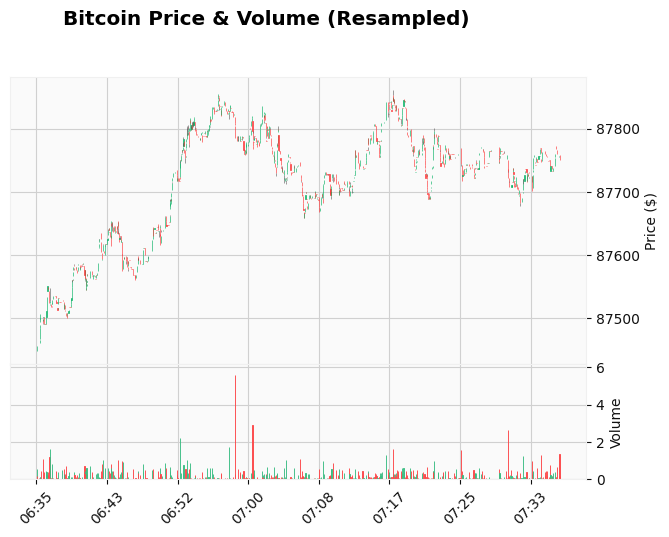

In [7]:
import mplfinance as mpf

# Ensure columns are titled exactly as mplfinance expects:
# 'Open', 'High', 'Low', 'Close', 'Volume'
# (If you followed the previous step, they should be ready)

# Plot parameters:
# type='candle': Uses candlestick bodies
# volume=True: Adds the volume bar chart at the bottom
# style='yahoo': Uses standard green/red coloring
# title: Helps the user identify the batch
mpf.plot(resampled_df, 
         type='candle', 
         volume=True, 
         style='yahoo', 
         title='Bitcoin Price & Volume (Resampled)',
         ylabel='Price ($)',
         ylabel_lower='Volume')

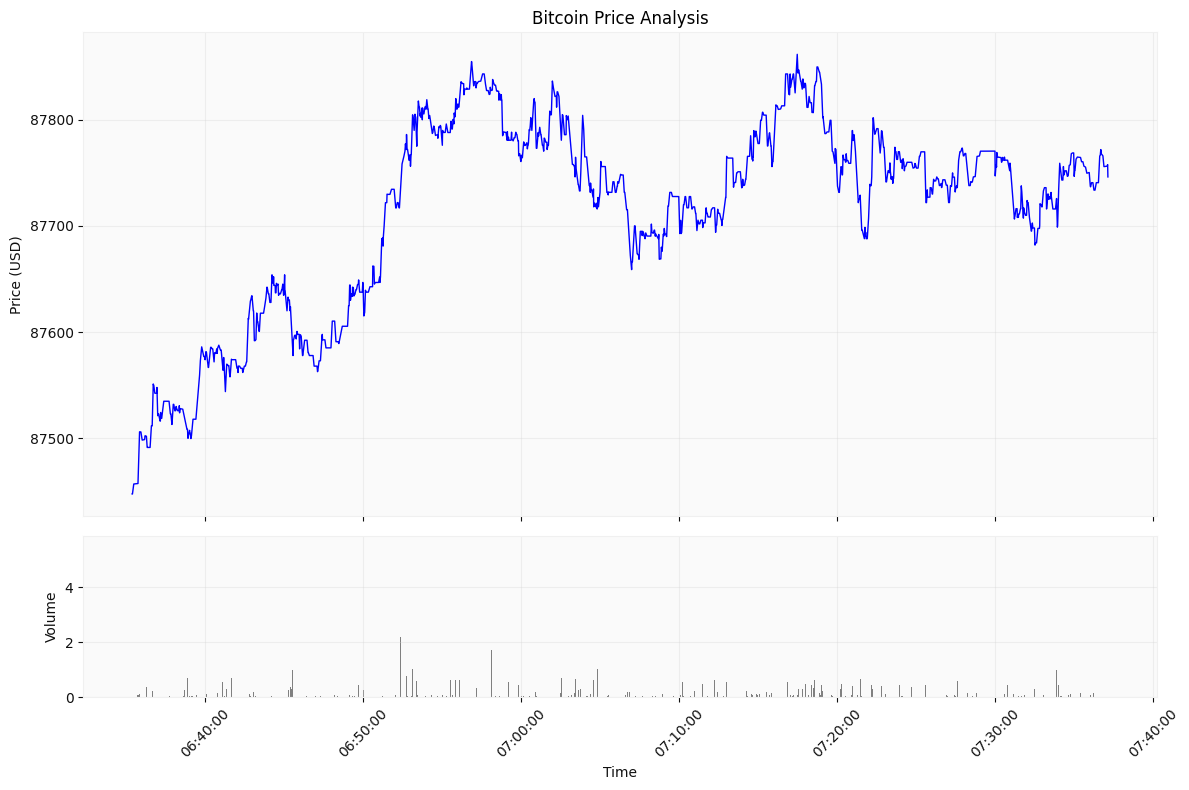

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create a figure with two subplots (Price on top, Volume on bottom)
# gridspec_kw={'height_ratios': [3, 1]} makes the price chart 3x taller than volume
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top Chart: Price ---
ax1.plot(resampled_df_noindex['time_exchange'], resampled_df['high'], color='blue', linewidth=1)
ax1.set_title('Bitcoin Price Analysis')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# Optional: Add markers if data is sparse
# ax1.scatter(resampled_df.index, resampled_df['Close'], s=10)

# --- Bottom Chart: Volume ---
ax2.bar(resampled_df.index, resampled_df['volume'], color='gray', width=0.00001) 
# Note: 'width' depends on your time scale. For 1S resample, width needs to be small.
# If the bars look too fat/thin, adjust 'width'. 

ax2.set_ylabel('Volume')
ax2.set_xlabel('Time')
ax2.grid(True, alpha=0.3)

# Format the x-axis times nicely
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Add plots method
#  cloud watch
# stocl p[rice data]

In [ ]:
# https://github.com/AzulGarza/timescale-and-large-time-models/tree/main

In [9]:
# run TimeCopilot
from timecopilot import TimeCopilot

# Load the dataset
# The DataFrame must include at least the following columns:
# - unique_id: Unique identifier for each time series (string)
# - ds: Date column (datetime format)
# - y: Target variable for forecasting (float format)
# The pandas frequency will be inferred from the ds column, if not provided.
# If the seasonality is not provided, it will be inferred based on the frequency. 
# If the horizon is not set, it will default to 2 times the inferred seasonality.

# Initialize the forecasting agent
# You can use any LLM by specifying the model parameter
tc = TimeCopilot(
    llm="openai:gpt-4o",
    retries=3,
)
# Generate forecast
# You can optionally specify the following parameters:
# - freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
# - h: The forecast horizon, which is the number of periods to predict
# - seasonality: The seasonal period of your data, which can be inferred if not provided
resampled_df_noindex = resampled_df_noindex.rename(columns={'time_exchange': 'ds', "open": "y"})
# resampled_df = resampled_df.rename(columns={"open": "y"})

result = tc.forecast(df=resampled_df_noindex, freq="s")

# df_subset = df.tail(500) # by rows
# result = tc.forecast(df=df_subset, freq="MS")


0it [00:00, ?it/s]
Traceback (most recent call last):
  File "c:\Users\alebr\Desktop\Engineering\AO\Projects\timecopilot\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\alebr\AppData\Local\Temp\ipykernel_35128\3054659272.py", line 27, in <module>
    result = tc.forecast(df=resampled_df_noindex, freq="s")
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alebr\Desktop\Engineering\AO\Projects\timecopilot\timecopilot\agent.py", line 1256, in forecast
    return self.analyze(df=df, h=h, freq=freq, seasonality=seasonality, query=query)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alebr\Desktop\Engineering\AO\Projects\timecopilot\timecopilot\agent.py", line 1203, in analyze
    result = self.forecasting_agent.run_sync(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alebr\Desktop\Engineerin

In [11]:
# resampled_df = resampled_df.rename(columns={'time_coinapi': 'ds'})
print(resampled_df.size)


18535


In [ ]:
df = df.rename(columns={'time_exchange': 'ds', "price": "y"})
print(df)


In [ ]:
df.size